# Forest Cover Type Classification Project

#### A complete, end‑to‑end workflow that loads the UCI Forest Cover Type dataset, explores the data, trains
#### three different models (Logistic Regression, Random Forest, LightGBM with Optuna hyper‑parameter search),
#### evaluates them, and visualises the results.





# ☢ **Estimated time:** approximately 2 hours 30 minutes to run

# 0.  Install & import libraries
#### Install all required third‑party packages (quietly) and load Python libraries we will need later.

In [1]:
!pip install -q ucimlrepo scikit-learn lightgbm optuna shap imbalanced-learn seaborn matplotlib plotly pandas numpy

import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from ucimlrepo import fetch_ucirepo

from sklearn.model_selection import train_test_split, cross_val_score, learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, f1_score, confusion_matrix,
                            classification_report, ConfusionMatrixDisplay)

import lightgbm as lgb
import optuna
import shap
from imblearn.over_sampling import SMOTE
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.graph_objects as go

warnings.filterwarnings("ignore")

print("Libraries loaded successfully!")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 386.6/386.6 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 231.9/231.9 kB 7.1 MB/s eta 0:00:00
Libraries loaded successfully!


# 1. Data loading & basic exploration
#### * Fetch the **Forest Cover Type** dataset (UCI id 31).
#### * Inspect shape, feature types and class distribution.

In [2]:
print("\n" + "="*80)
print("1. DATA LOADING AND EXPLORATION")
print("="*80)


print("Fetching the Forest Cover Type dataset...")
cov = fetch_ucirepo(id=31)
X, y = cov.data.features, cov.data.targets.squeeze()


print(f"\nDataset Shape: {X.shape}")
print(f"Number of Classes: {len(np.unique(y))}")
print(f"Class Labels: {np.unique(y)}")
print(f"Number of Features: {X.shape[1]}")

print("\nFeature Types:")
print(f"Numerical Features: {sum(~X.columns.str.startswith(('Wilderness', 'Soil_Type')))}")
print(f"Binary Features: {sum(X.columns.str.startswith(('Wilderness', 'Soil_Type')))}")


print("\nClass Distribution:")
class_dist = y.value_counts().sort_index()
for class_label, count in class_dist.items():
    print(f"Class {class_label}: {count} samples ({count/len(y)*100:.2f}%)")


num_cols = X.columns[~X.columns.str.startswith(("Wilderness", "Soil_Type"))]
bin_cols = X.columns.difference(num_cols)

print("\nStatistics for Numerical Features:")
X_num_desc = X[num_cols].describe().T
print(X_num_desc)


1. DATA LOADING AND EXPLORATION
Fetching the Forest Cover Type dataset...

Dataset Shape: (581012, 54)
Number of Classes: 7
Class Labels: [1 2 3 4 5 6 7]
Number of Features: 54

Feature Types:
Numerical Features: 10
Binary Features: 44

Class Distribution:
Class 1: 211840 samples (36.46%)
Class 2: 283301 samples (48.76%)
Class 3: 35754 samples (6.15%)
Class 4: 2747 samples (0.47%)
Class 5: 9493 samples (1.63%)
Class 6: 17367 samples (2.99%)
Class 7: 20510 samples (3.53%)

Statistics for Numerical Features:
                                       count         mean          std  \
Elevation                           581012.0  2959.365301   279.984734   
Aspect                              581012.0   155.656807   111.913721   
Slope                               581012.0    14.103704     7.488242   
Horizontal_Distance_To_Hydrology    581012.0   269.428217   212.549356   
Vertical_Distance_To_Hydrology      581012.0    46.418855    58.295232   
Horizontal_Distance_To_Roadways     581012.

# 2.  Data visualisation
#### A few quick visuals to understand class imbalance and relationships between key terrain features.



2. DATA VISUALIZATION


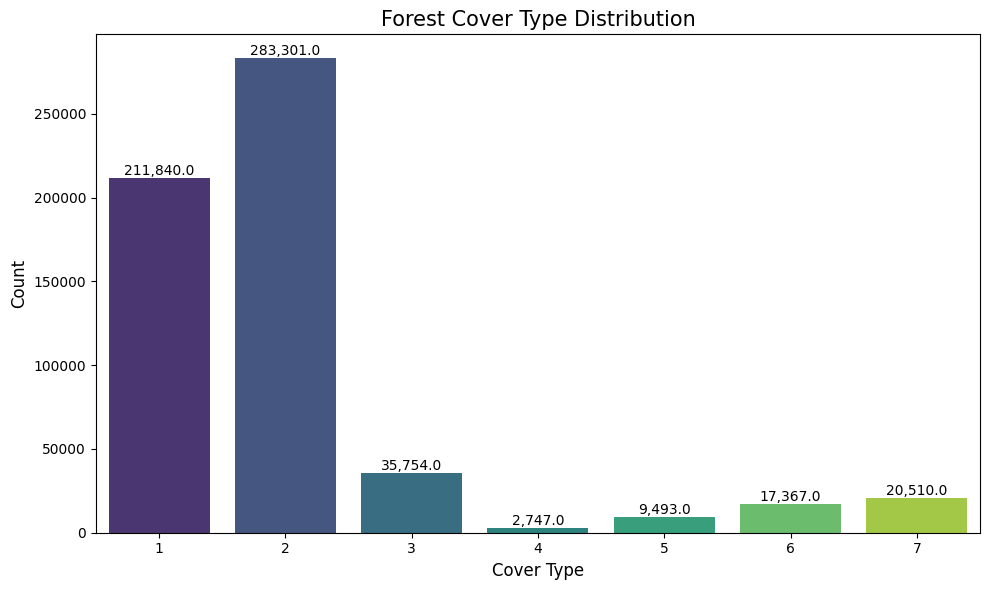

In [3]:
print("\n" + "="*80)
print("2. DATA VISUALIZATION")
print("="*80)

plt.figure(figsize=(10, 6))
ax = sns.countplot(x=y, palette='viridis')
plt.title("Forest Cover Type Distribution", fontsize=15)
plt.xlabel("Cover Type", fontsize=12)
plt.ylabel("Count", fontsize=12)

for p in ax.patches:
    ax.annotate(f'{p.get_height():,}',(p.get_x() + p.get_width() / 2., p.get_height()),ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()


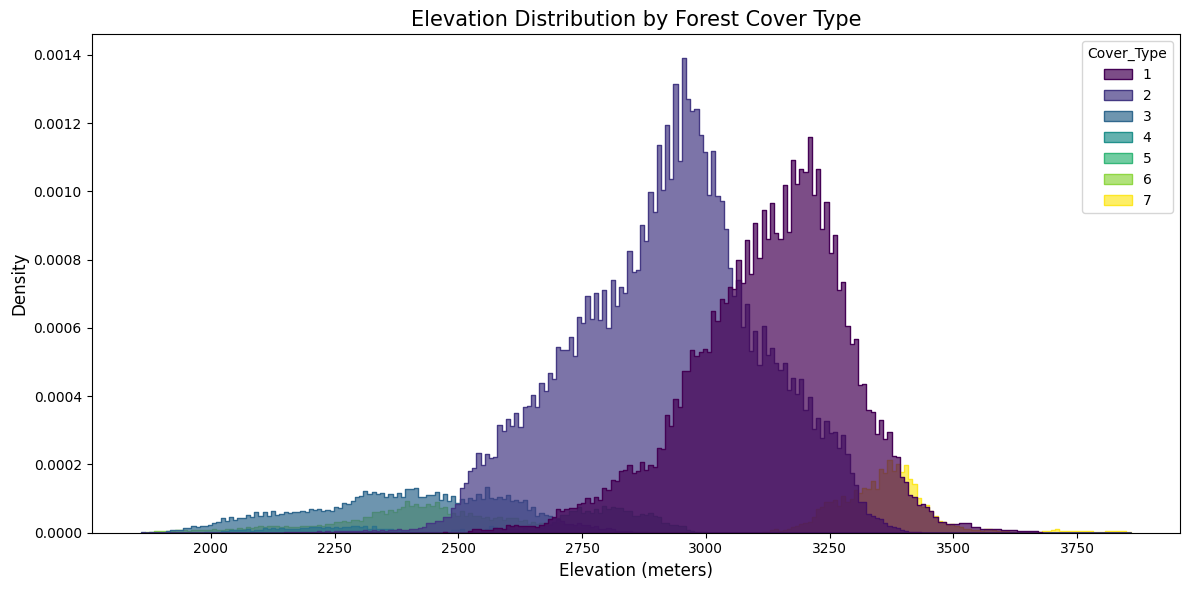

In [4]:
plt.figure(figsize=(12, 6))
sns.histplot(data=pd.concat([X["Elevation"], y], axis=1),
             x="Elevation", hue="Cover_Type", element="step",
             stat="density", palette='viridis', alpha=0.7)
plt.title("Elevation Distribution by Forest Cover Type", fontsize=15)
plt.xlabel("Elevation (meters)", fontsize=12)
plt.ylabel("Density", fontsize=12)
plt.tight_layout()
plt.show()

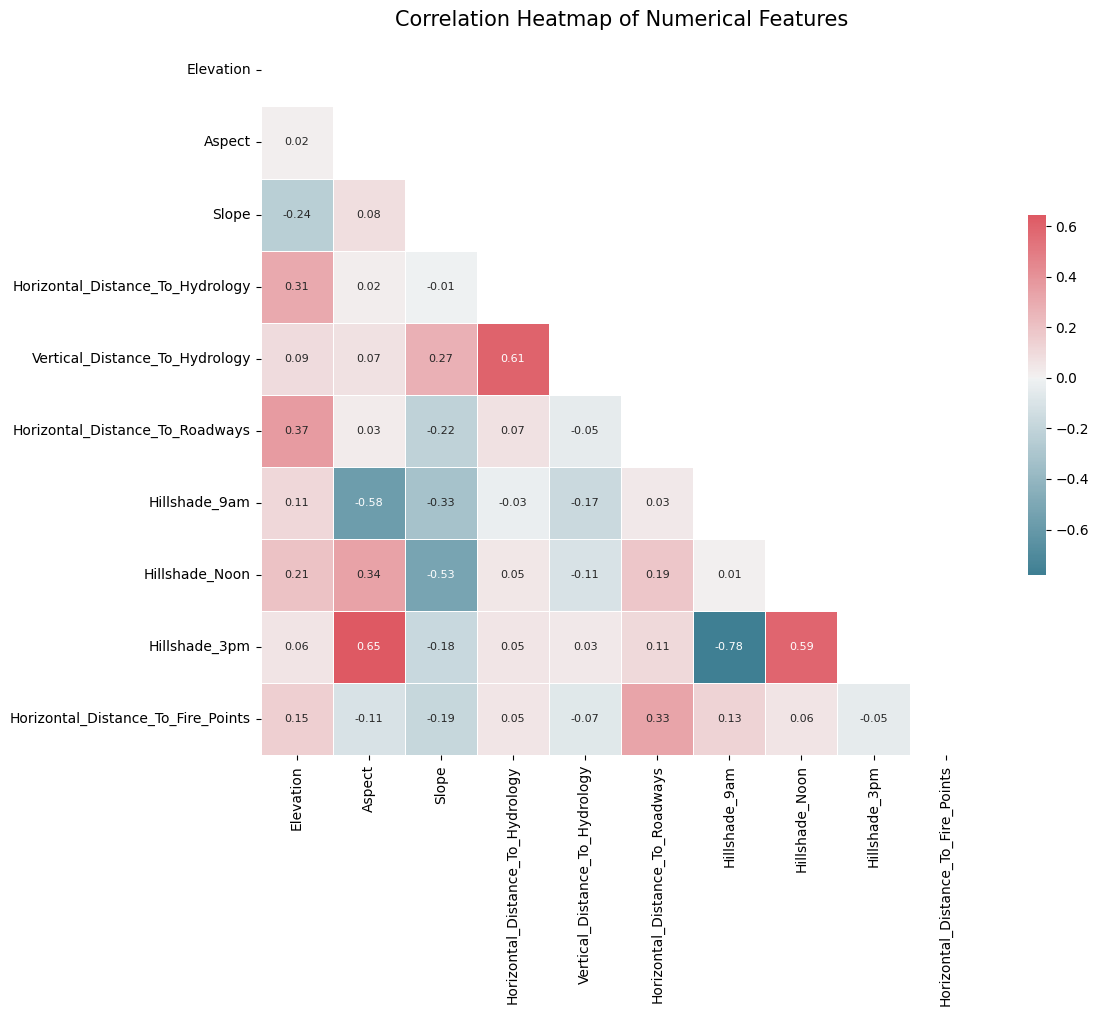

In [5]:
plt.figure(figsize=(12, 10))
corr = X[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
cmap = sns.diverging_palette(220, 10, as_cmap=True)
sns.heatmap(corr, mask=mask, cmap=cmap, center=0, square=True, linewidths=.5,cbar_kws={"shrink": .5}, annot=True, fmt=".2f", annot_kws={"size": 8})
plt.title("Correlation Heatmap of Numerical Features", fontsize=15)
plt.tight_layout()
plt.show()

In [6]:
def plot_feature_importance():

    rf = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)
    rf.fit(X_train, y_train)

    importance = rf.feature_importances_
    indices = np.argsort(importance)[::-1]

    plt.figure(figsize=(12, 8))
    sns.barplot(x=importance[indices[:15]], y=X.columns[indices[:15]], palette='viridis')
    plt.title("Top 15 Most Important Features (Random Forest)", fontsize=15)
    plt.xlabel("Relative Importance", fontsize=12)
    plt.tight_layout()
    plt.show()

    return rf

def plot_terrain_features():
    terrain_features = ['Elevation', 'Aspect', 'Slope', 'Horizontal_Distance_To_Hydrology',
                       'Vertical_Distance_To_Hydrology', 'Horizontal_Distance_To_Roadways',
                       'Hillshade_9am', 'Hillshade_Noon', 'Hillshade_3pm',
                       'Horizontal_Distance_To_Fire_Points']

    terrain_data = pd.concat([X[terrain_features].sample(10000, random_state=RANDOM_STATE),y.sample(10000, random_state=RANDOM_STATE)], axis=1)

    fig, axes = plt.subplots(2, 5, figsize=(20, 8))
    axes = axes.flatten()

    for i, feature in enumerate(terrain_features):
        sns.kdeplot(data=terrain_data, x=feature, hue='Cover_Type', ax=axes[i], palette='tab10')
        axes[i].set_title(f'Distribution of {feature}')

    plt.tight_layout()
    plt.show()

def create_3d_plot():
    sample_size = min(10000, len(X))
    idx = np.random.choice(X.shape[0], size=sample_size, replace=False)
    X_sample = X.iloc[idx]
    y_sample = y.iloc[idx]

    fig = px.scatter_3d(
        x=X_sample['Elevation'],
        y=X_sample['Slope'],
        z=X_sample['Aspect'],
        color=y_sample.astype(str),
        labels={'x': 'Elevation', 'y': 'Slope', 'z': 'Aspect'},
        title="3D Visualization of Key Terrain Features",
        color_discrete_sequence=px.colors.qualitative.Vivid
    )

    fig.update_layout(
        scene=dict(
            xaxis_title='Elevation (m)',
            yaxis_title='Slope (degrees)',
            zaxis_title='Aspect (degrees)'
        ),
        width=900,
        height=700
    )

    fig.show()

# 3.  Pre‑processing
#### * Train/validation/test split (60 / 20 / 20) stratified by class.
#### * Standardise numeric columns.

In [7]:
print("\n" + "="*80)
print("3. DATA PREPROCESSING")
print("="*80)

print("Splitting data into training, validation, and test sets...")
X_train, X_tmp, y_train, y_tmp = train_test_split(X, y, test_size=0.4,
                                                 stratify=y, random_state=RANDOM_STATE)
X_val, X_test, y_val, y_test = train_test_split(X_tmp, y_tmp, test_size=0.5,
                                               stratify=y_tmp, random_state=RANDOM_STATE)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Validation set: {X_val.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

print("\nStandardizing numerical features...")
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_val_scaled = X_val.copy()
X_test_scaled = X_test.copy()

X_train_scaled[num_cols] = scaler.fit_transform(X_train[num_cols])
X_val_scaled[num_cols] = scaler.transform(X_val[num_cols])
X_test_scaled[num_cols] = scaler.transform(X_test[num_cols])

print("Data preprocessing completed!")



3. DATA PREPROCESSING
Splitting data into training, validation, and test sets...
Training set: 348607 samples
Validation set: 116202 samples
Test set: 116203 samples

Standardizing numerical features...
Data preprocessing completed!



Generating feature importance plot...


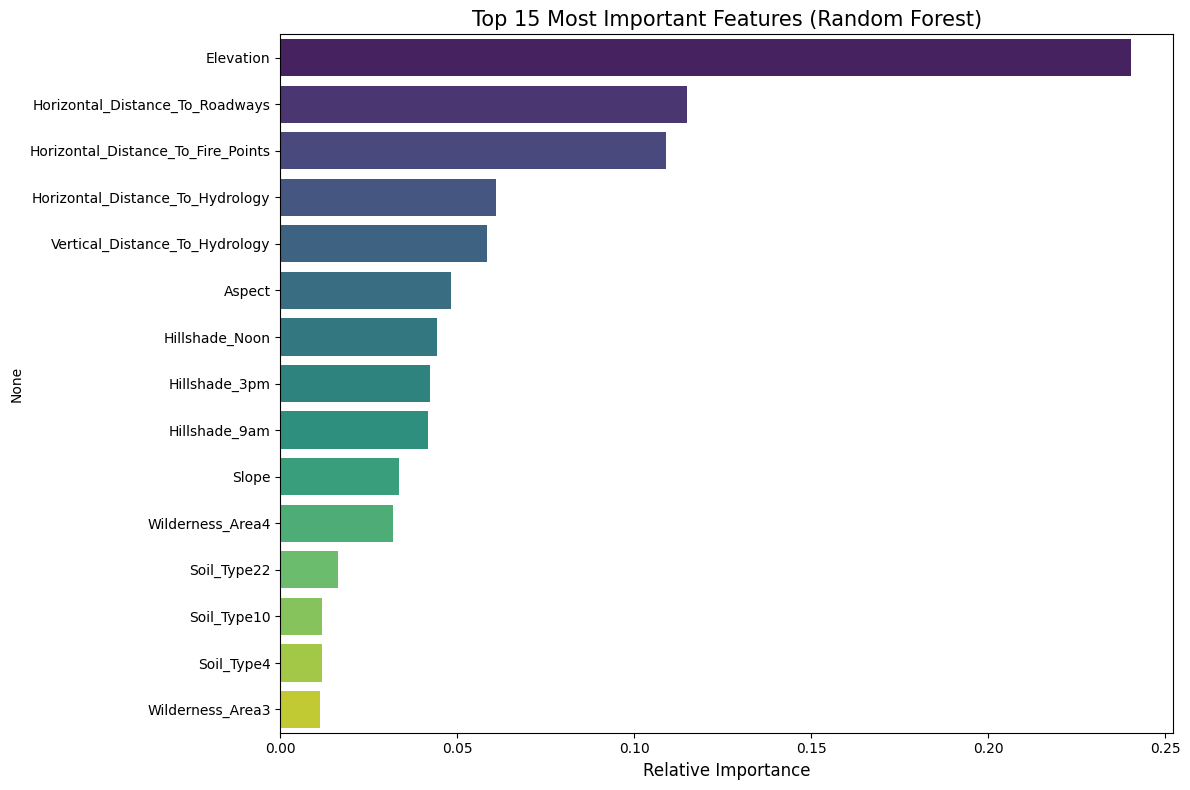

In [8]:
print("\nGenerating feature importance plot...")
rf_model = plot_feature_importance()


Generating terrain feature distributions...


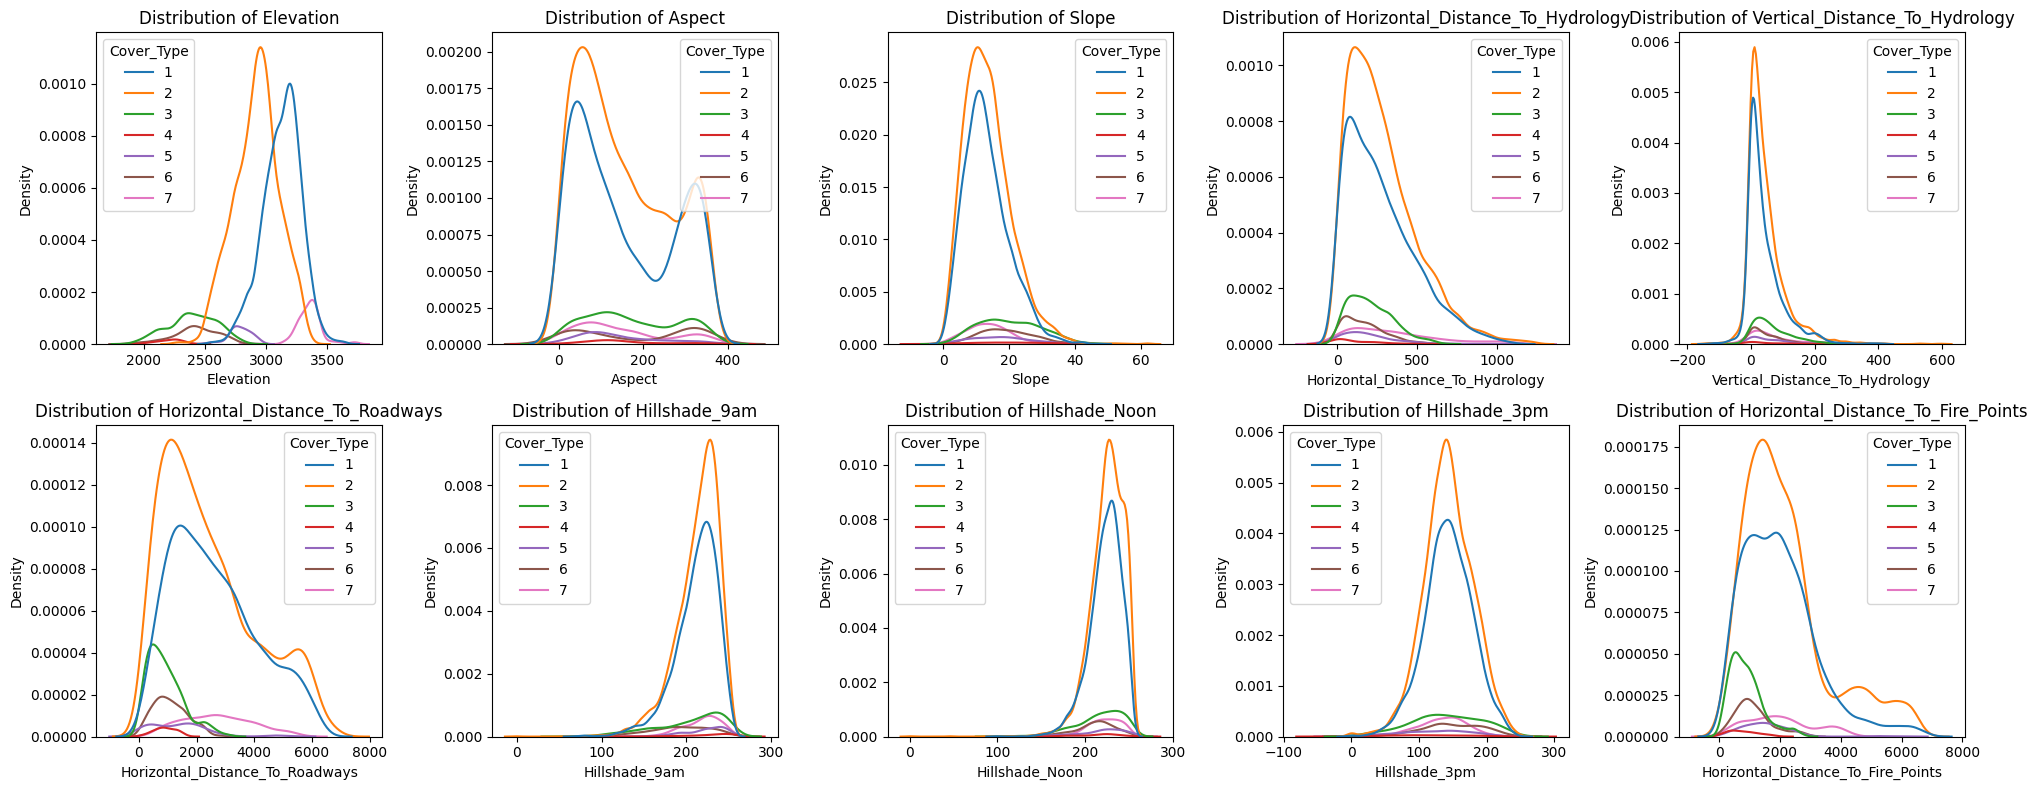

In [9]:
print("\nGenerating terrain feature distributions...")
plot_terrain_features()

In [10]:
print("\nGenerating 3D interactive plot...")
create_3d_plot()


Generating 3D interactive plot...


# 4.  Model implementation
### I train three very different algorithms:

#### 1. **Logistic Regression** (multinomial, saga solver)
#### 2. **Random Forest**
#### 3. **LightGBM**

In [11]:
print("\n" + "="*80)
print("4. MODEL IMPLEMENTATION")
print("="*80)

model_results = {}

print("\n4.1 Logistic Regression")
print("-" * 40)

logreg = Pipeline([
    ("scale", StandardScaler(with_mean=False)),
    ("clf", LogisticRegression(C=1.0, solver="saga", max_iter=4000, n_jobs=-1, random_state=RANDOM_STATE))
])

print("Training Logistic Regression model...")
logreg.fit(X_train, y_train)

print("Evaluating on validation set...")
logreg_val_preds = logreg.predict(X_val)
logreg_val_acc = accuracy_score(y_val, logreg_val_preds)
logreg_val_f1 = f1_score(y_val, logreg_val_preds, average="macro")

print(f"Validation Accuracy: {logreg_val_acc:.4f}")
print(f"Validation Macro F1: {logreg_val_f1:.4f}")

model_results["Logistic Regression"] = {
    "model": logreg,
    "val_accuracy": logreg_val_acc,
    "val_f1": logreg_val_f1
}


4. MODEL IMPLEMENTATION

4.1 Logistic Regression
----------------------------------------
Training Logistic Regression model...
Evaluating on validation set...
Validation Accuracy: 0.7204
Validation Macro F1: 0.5175


In [12]:
print("\n4.2 Random Forest")
print("-" * 40)

print("Using the previously trained Random Forest model...")
rf_val_preds = rf_model.predict(X_val)
rf_val_acc = accuracy_score(y_val, rf_val_preds)
rf_val_f1 = f1_score(y_val, rf_val_preds, average="macro")

print(f"Validation Accuracy: {rf_val_acc:.4f}")
print(f"Validation Macro F1: {rf_val_f1:.4f}")

model_results["Random Forest"] = {
    "model": rf_model,
    "val_accuracy": rf_val_acc,
    "val_f1": rf_val_f1
}



4.2 Random Forest
----------------------------------------
Using the previously trained Random Forest model...
Validation Accuracy: 0.9474
Validation Macro F1: 0.9133


In [13]:
print("\n4.3 LightGBM with Optuna Hyperparameter Tuning")
print("-" * 40)

y_train_lgb = y_train - 1
y_val_lgb = y_val - 1

def objective(trial):
    params = dict(
        objective="multiclass",
        num_class=7,
        metric="multi_logloss",
        num_leaves=trial.suggest_int("num_leaves", 31, 96),
        learning_rate=trial.suggest_float("learning_rate", 0.03, 0.2, log=True),
        feature_fraction=trial.suggest_float("feature_fraction", 0.75, 1.0),
        bagging_fraction=trial.suggest_float("bagging_fraction", 0.75, 1.0),
        bagging_freq=1,
        verbose=-1,
    )

    booster = lgb.train(
        params,
        lgb.Dataset(X_train, label=y_train_lgb),
        num_boost_round=250,
        valid_sets=[lgb.Dataset(X_val, label=y_val_lgb)],
        callbacks=[
            lgb.early_stopping(stopping_rounds=25),
            lgb.log_evaluation(period=0)
        ]
    )

    preds_val = booster.predict(X_val).argmax(1) + 1
    return f1_score(y_val, preds_val, average="macro")


print("Optimizing LightGBM hyperparameters using Optuna...")
print("This might take a few minutes...")

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=20)

print(f"Best Macro-F1: {study.best_value:.4f}")
print(f"Best params: {study.best_params}")

best_params = study.best_params
lgbm = lgb.LGBMClassifier(
    objective="multiclass",
    num_class=7,
    n_estimators=250,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    **best_params,
)

print("Training final LightGBM model with optimized hyperparameters...")
lgbm.fit(
    X_train, y_train_lgb,
    eval_set=[(X_val, y_val_lgb)],
    callbacks=[lgb.log_evaluation(period=0)]
)

def lgbm_predict(X):
    return lgbm.predict(X).astype(int) + 1

lgbm_val_preds = lgbm_predict(X_val)
lgbm_val_acc = accuracy_score(y_val, lgbm_val_preds)
lgbm_val_f1 = f1_score(y_val, lgbm_val_preds, average="macro")

print(f"Validation Accuracy: {lgbm_val_acc:.4f}")
print(f"Validation Macro F1: {lgbm_val_f1:.4f}")

model_results["LightGBM"] = {
    "model": lgbm,
    "val_accuracy": lgbm_val_acc,
    "val_f1": lgbm_val_f1
}


[I 2025-05-02 15:52:42,233] A new study created in memory with name: no-name-574064b3-057d-4a20-80c3-015cc7f354fb



4.3 LightGBM with Optuna Hyperparameter Tuning
----------------------------------------
Optimizing LightGBM hyperparameters using Optuna...
This might take a few minutes...
Training until validation scores don't improve for 25 rounds
Early stopping, best iteration is:
[39]	valid_0's multi_logloss: 0.311087


[I 2025-05-02 15:53:15,209] Trial 0 finished with value: 0.8588641421720159 and parameters: {'num_leaves': 92, 'learning_rate': 0.16190495653989598, 'feature_fraction': 0.8387793793312045, 'bagging_fraction': 0.9195924701818805}. Best is trial 0 with value: 0.8588641421720159.


Training until validation scores don't improve for 25 rounds
Did not meet early stopping. Best iteration is:
[250]	valid_0's multi_logloss: 0.251414


[I 2025-05-02 15:55:03,285] Trial 1 finished with value: 0.8997623054322252 and parameters: {'num_leaves': 54, 'learning_rate': 0.06387562333678933, 'feature_fraction': 0.934874143211559, 'bagging_fraction': 0.8657503454250732}. Best is trial 1 with value: 0.8997623054322252.


...

Training until validation scores don't improve for 25 rounds
Early stopping, best iteration is:
[126]	valid_0's multi_logloss: 0.278213


[I 2025-05-02 16:20:28,957] Trial 18 finished with value: 0.8870615836120213 and parameters: {'num_leaves': 66, 'learning_rate': 0.08595332864883402, 'feature_fraction': 0.9542062163512356, 'bagging_fraction': 0.8286505249031737}. Best is trial 17 with value: 0.9133035926849383.


Training until validation scores don't improve for 25 rounds
Early stopping, best iteration is:
[54]	valid_0's multi_logloss: 0.412062


[I 2025-05-02 16:20:56,626] Trial 19 finished with value: 0.805593473329245 and parameters: {'num_leaves': 32, 'learning_rate': 0.11862598012052536, 'feature_fraction': 0.9591393263078539, 'bagging_fraction': 0.9531101772295822}. Best is trial 17 with value: 0.9133035926849383.


Best Macro-F1: 0.9133
Best params: {'num_leaves': 67, 'learning_rate': 0.08142986536373281, 'feature_fraction': 0.9541784940082827, 'bagging_fraction': 0.7992742597147939}
Training final LightGBM model with optimized hyperparameters...
Validation Accuracy: 0.9254
Validation Macro F1: 0.9115


# 5. Evaluation on the held‑out test set


5. MODEL EVALUATION ON TEST SET

Evaluating Logistic Regression...
Test Accuracy: 0.7246
Test Macro F1: 0.5207


<Figure size 1000x800 with 0 Axes>

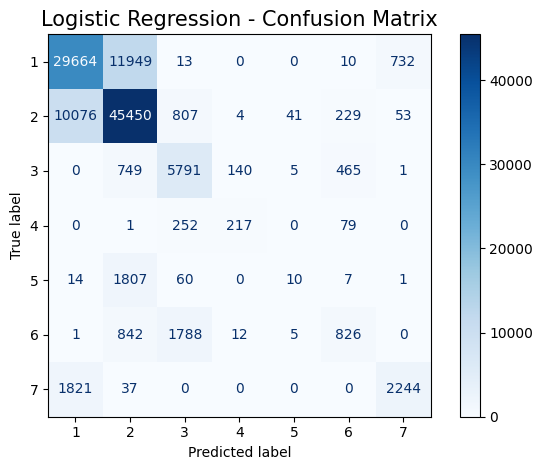


Classification Report:
              precision    recall  f1-score   support

           1       0.71      0.70      0.71     42368
           2       0.75      0.80      0.77     56660
           3       0.66      0.81      0.73      7151
           4       0.58      0.40      0.47       549
           5       0.16      0.01      0.01      1899
           6       0.51      0.24      0.32      3474
           7       0.74      0.55      0.63      4102

    accuracy                           0.72    116203
   macro avg       0.59      0.50      0.52    116203
weighted avg       0.71      0.72      0.71    116203



In [14]:
print("\n" + "="*80)
print("5. MODEL EVALUATION ON TEST SET")
print("="*80)


def evaluate_model(name, model, is_lgbm=False):
    print(f"\nEvaluating {name}...")

    if is_lgbm:
        y_pred = lgbm_predict(X_test)
    else:
        y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    macro_f1 = f1_score(y_test, y_pred, average="macro")

    model_results[name]["test_accuracy"] = accuracy
    model_results[name]["test_f1"] = macro_f1

    print(f"Test Accuracy: {accuracy:.4f}")
    print(f"Test Macro F1: {macro_f1:.4f}")

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(10, 8))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=range(1, 8))
    disp.plot(cmap="Blues", values_format="d")
    plt.title(f"{name} - Confusion Matrix", fontsize=15)
    plt.tight_layout()
    plt.show()

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    return y_pred

logreg_preds = evaluate_model("Logistic Regression", logreg)


Evaluating Random Forest...
Test Accuracy: 0.9482
Test Macro F1: 0.9150


<Figure size 1000x800 with 0 Axes>

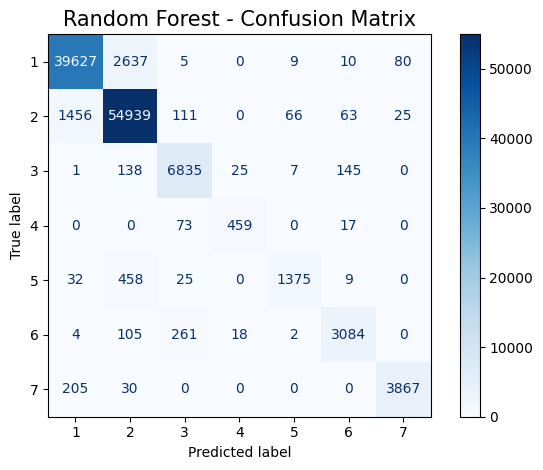


Classification Report:
              precision    recall  f1-score   support

           1       0.96      0.94      0.95     42368
           2       0.94      0.97      0.96     56660
           3       0.94      0.96      0.95      7151
           4       0.91      0.84      0.87       549
           5       0.94      0.72      0.82      1899
           6       0.93      0.89      0.91      3474
           7       0.97      0.94      0.96      4102

    accuracy                           0.95    116203
   macro avg       0.94      0.89      0.92    116203
weighted avg       0.95      0.95      0.95    116203



In [15]:
rf_preds = evaluate_model("Random Forest", rf_model)


Evaluating LightGBM...
Test Accuracy: 0.9251
Test Macro F1: 0.9121


<Figure size 1000x800 with 0 Axes>

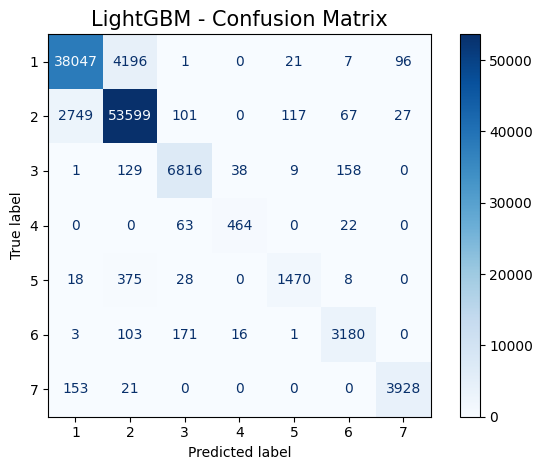


Classification Report:
              precision    recall  f1-score   support

           1       0.93      0.90      0.91     42368
           2       0.92      0.95      0.93     56660
           3       0.95      0.95      0.95      7151
           4       0.90      0.85      0.87       549
           5       0.91      0.77      0.84      1899
           6       0.92      0.92      0.92      3474
           7       0.97      0.96      0.96      4102

    accuracy                           0.93    116203
   macro avg       0.93      0.90      0.91    116203
weighted avg       0.93      0.93      0.92    116203



In [16]:
lgbm_preds = evaluate_model("LightGBM", lgbm, is_lgbm=True)

# 6.  Results visualisation & comparison

In [17]:
print("\n" + "="*80)
print("6. RESULTS VISUALIZATION AND COMPARISON")
print("="*80)

def plot_model_comparison():
    model_names = list(model_results.keys())
    val_accuracy = [model_results[name]["val_accuracy"] for name in model_names]
    val_f1 = [model_results[name]["val_f1"] for name in model_names]
    test_accuracy = [model_results[name]["test_accuracy"] for name in model_names]
    test_f1 = [model_results[name]["test_f1"] for name in model_names]

    x = np.arange(len(model_names))
    width = 0.2

    fig, ax = plt.subplots(figsize=(12, 8))
    ax.bar(x - width*1.5, val_accuracy, width, label='Validation Accuracy', color='skyblue')
    ax.bar(x - width/2, val_f1, width, label='Validation F1', color='lightgreen')
    ax.bar(x + width/2, test_accuracy, width, label='Test Accuracy', color='coral')
    ax.bar(x + width*1.5, test_f1, width, label='Test F1', color='plum')

    ax.set_ylim(0, 1.0)
    ax.set_ylabel('Score', fontsize=14)
    ax.set_title('Model Performance Comparison', fontsize=16)
    ax.set_xticks(x)
    ax.set_xticklabels(model_names, fontsize=12)
    ax.legend(fontsize=12)

    for i, x_pos in enumerate(x):
        metrics = [val_accuracy[i], val_f1[i], test_accuracy[i], test_f1[i]]
        positions = [x_pos - width*1.5, x_pos - width/2, x_pos + width/2, x_pos + width*1.5]

        for pos, metric in zip(positions, metrics):
            ax.text(pos, metric + 0.01, f'{metric:.3f}', ha='center', va='bottom', fontsize=9)

    plt.tight_layout()
    plt.show()


6. RESULTS VISUALIZATION AND COMPARISON


In [18]:
print("\n" + "="*80)
print("6. RESULTS VISUALIZATION AND COMPARISON")
print("="*80)

def plot_model_comparison():
    model_names = list(model_results.keys())
    val_accuracy = [model_results[name]["val_accuracy"] for name in model_names]
    val_f1 = [model_results[name]["val_f1"] for name in model_names]
    test_accuracy = [model_results[name]["test_accuracy"] for name in model_names]
    test_f1 = [model_results[name]["test_f1"] for name in model_names]

    x = np.arange(len(model_names))
    width = 0.2

    fig, ax = plt.subplots(figsize=(12, 8))
    ax.bar(x - width*1.5, val_accuracy, width, label='Validation Accuracy', color='skyblue')
    ax.bar(x - width/2, val_f1, width, label='Validation F1', color='lightgreen')
    ax.bar(x + width/2, test_accuracy, width, label='Test Accuracy', color='coral')
    ax.bar(x + width*1.5, test_f1, width, label='Test F1', color='plum')

    ax.set_ylim(0, 1.0)
    ax.set_ylabel('Score', fontsize=14)
    ax.set_title('Model Performance Comparison', fontsize=16)
    ax.set_xticks(x)
    ax.set_xticklabels(model_names, fontsize=12)
    ax.legend(fontsize=12)

    for i, x_pos in enumerate(x):
        metrics = [val_accuracy[i], val_f1[i], test_accuracy[i], test_f1[i]]
        positions = [x_pos - width*1.5, x_pos - width/2, x_pos + width/2, x_pos + width*1.5]

        for pos, metric in zip(positions, metrics):
            ax.text(pos, metric + 0.01, f'{metric:.3f}', ha='center', va='bottom', fontsize=9)

    plt.tight_layout()
    plt.show()


def plot_lgbm_feature_importance():
    importance = lgbm.feature_importances_
    feature_names = X.columns
    indices = np.argsort(importance)[::-1]
    plt.figure(figsize=(12, 8))
    sns.barplot(x=importance[indices[:15]], y=feature_names[indices[:15]], palette='viridis')
    plt.title("Top 15 Most Important Features (LightGBM)", fontsize=15)
    plt.xlabel("Relative Importance", fontsize=12)
    plt.tight_layout()
    plt.show()

def plot_class_performance():
    class_names = [f"Class {i}" for i in range(1, 8)]

    f1_scores = {
        "Logistic Regression": f1_score(y_test, logreg_preds, average=None),
        "Random Forest": f1_score(y_test, rf_preds, average=None),
        "LightGBM": f1_score(y_test, lgbm_preds, average=None)
    }

    f1_df = pd.DataFrame(f1_scores, index=class_names)
    plt.figure(figsize=(14, 8))
    f1_df.plot(kind='bar', width=0.8, figsize=(14, 8))
    plt.title("Per-Class F1 Score Comparison", fontsize=16)
    plt.xlabel("Cover Type", fontsize=14)
    plt.ylabel("F1 Score", fontsize=14)
    plt.ylim(0, 1.0)
    plt.legend(fontsize=12)
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_misclassification_analysis():
    rf_misclass = y_test != rf_preds
    lgbm_misclass = y_test != lgbm_preds
    logreg_misclass = y_test != logreg_preds

    misclass_count = rf_misclass.astype(int) + lgbm_misclass.astype(int) + logreg_misclass.astype(int)

    sample_size = min(5000, len(X_test))
    idx = np.random.choice(X_test.shape[0], size=sample_size, replace=False)

    X_test_sample = X_test.iloc[idx]
    y_test_sample = y_test.iloc[idx]
    misclass_count_sample = misclass_count.iloc[idx]

    fig = px.scatter_3d(
        x=X_test_sample['Elevation'],
        y=X_test_sample['Slope'],
        z=X_test_sample['Aspect'],
        color=misclass_count_sample,
        labels={'x': 'Elevation', 'y': 'Slope', 'z': 'Aspect', 'color': 'Models Misclassified'},
        title="Misclassification Analysis by Terrain Features",
        color_continuous_scale=px.colors.sequential.Plasma
    )

    fig.update_layout(
        scene=dict(
            xaxis_title='Elevation (m)',
            yaxis_title='Slope (degrees)',
            zaxis_title='Aspect (degrees)'
        ),
        width=900,
        height=700
    )

    fig.show()



6. RESULTS VISUALIZATION AND COMPARISON



Generating model comparison visualizations...


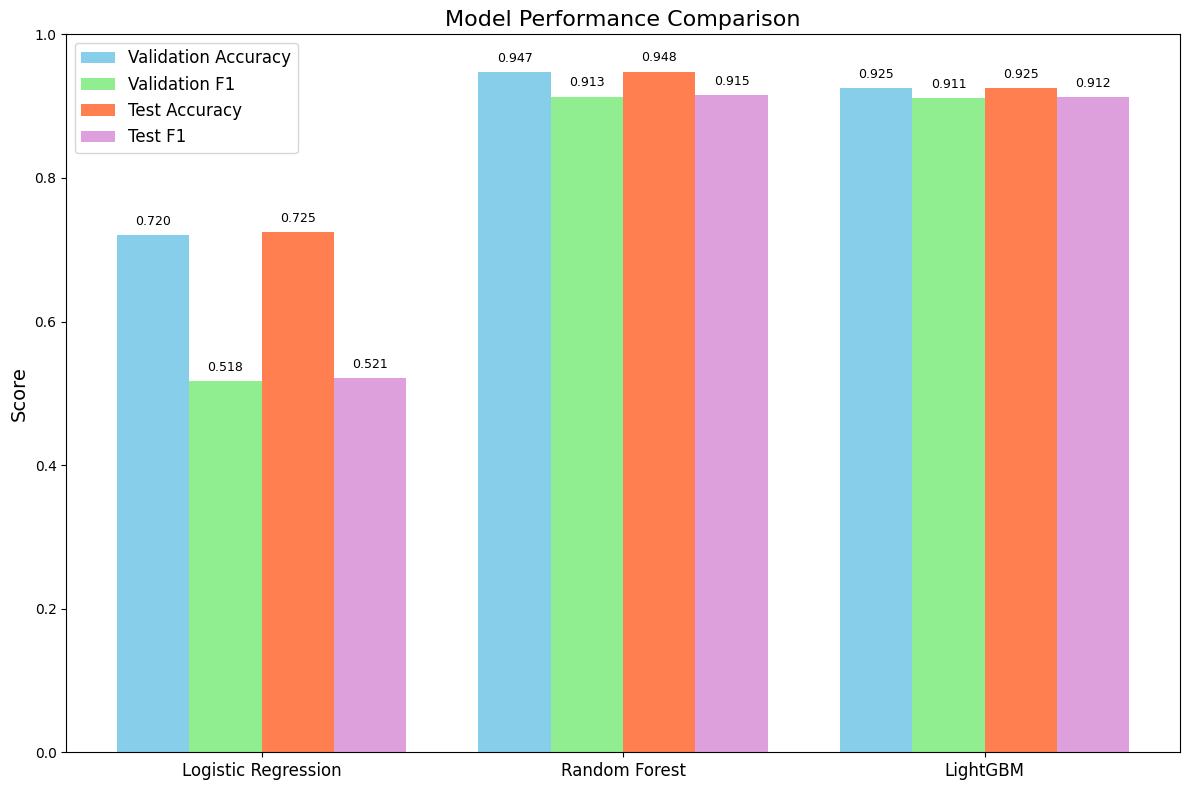

In [19]:
print("\nGenerating model comparison visualizations...")
plot_model_comparison()


Generating LightGBM feature importance plot...


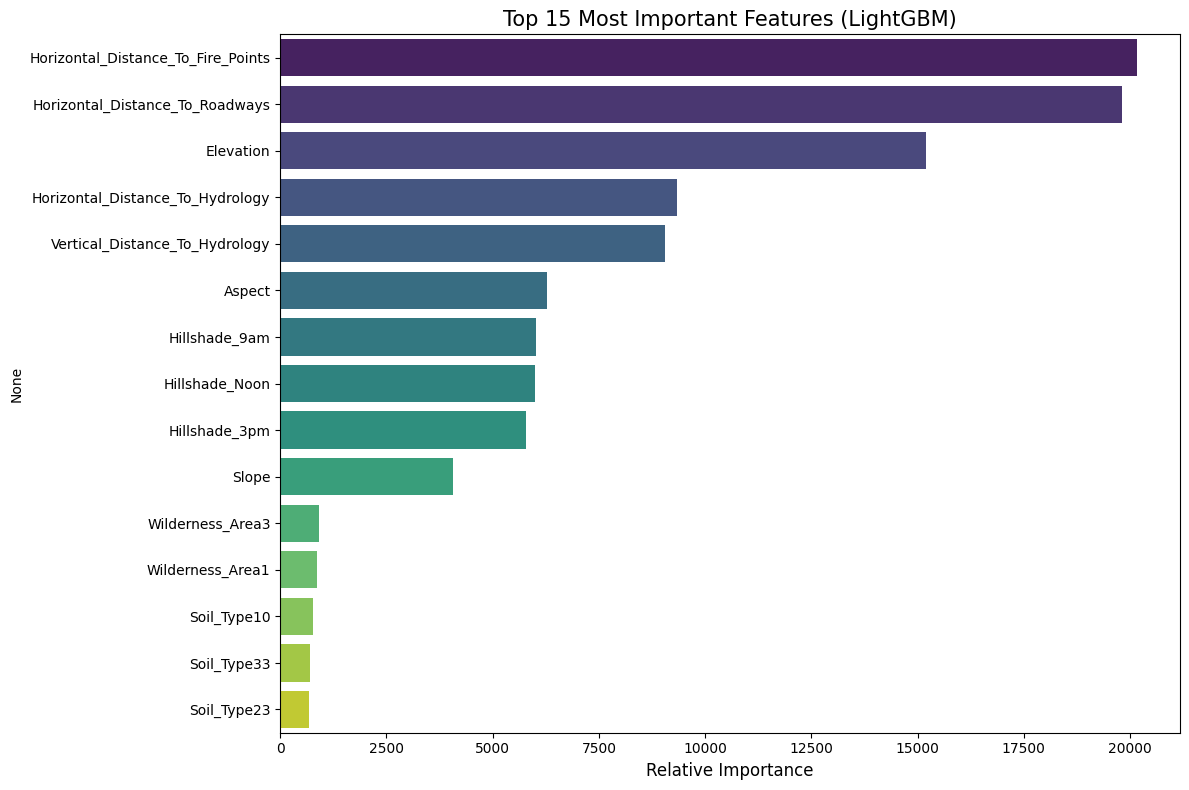

In [20]:
print("\nGenerating LightGBM feature importance plot...")
plot_lgbm_feature_importance()


Generating per-class performance comparison...


<Figure size 1400x800 with 0 Axes>

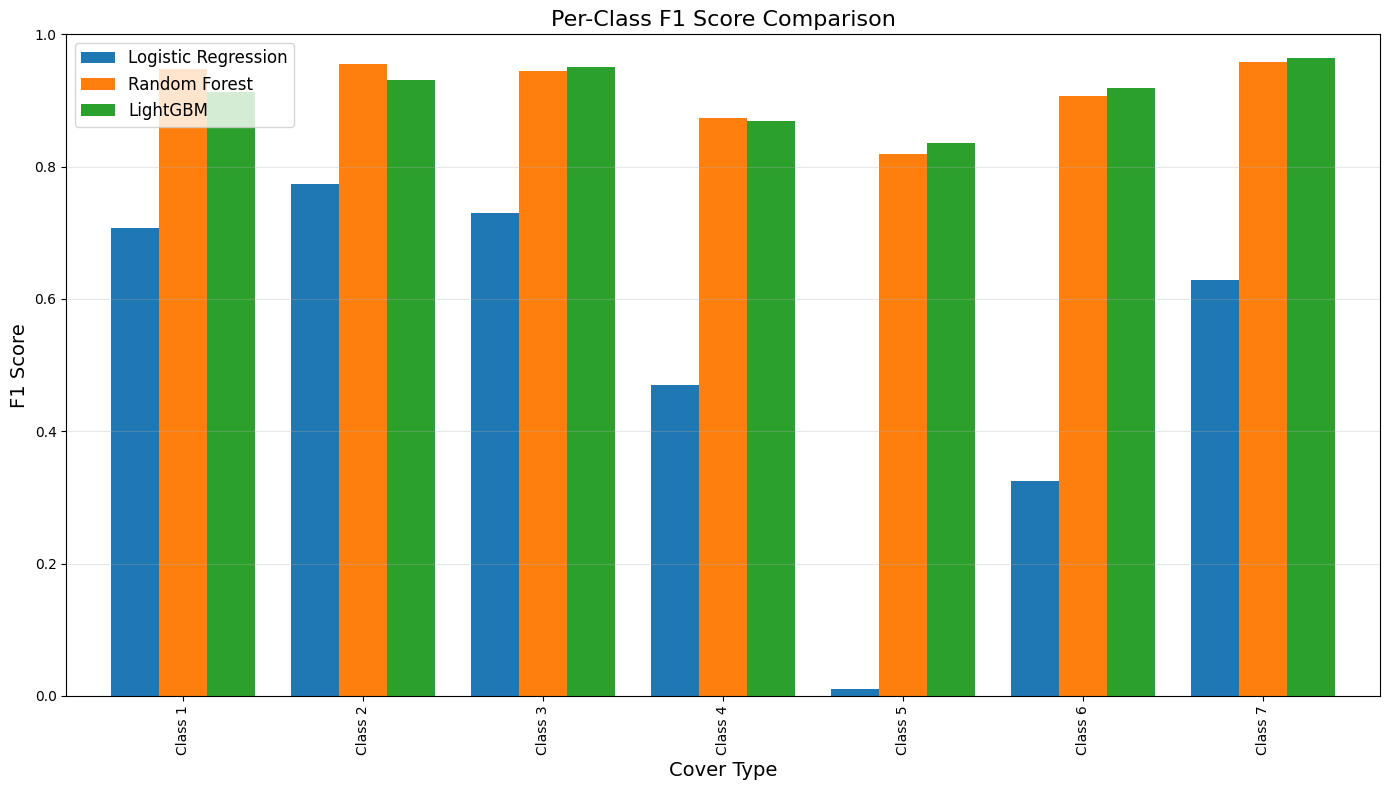

In [21]:

print("\nGenerating per-class performance comparison...")
plot_class_performance()


In [22]:

print("\nGenerating misclassification analysis...")
plot_misclassification_analysis()


Generating misclassification analysis...


# 7.  Conclusion

In [23]:
print("\n" + "="*80)
print("7. CONCLUSION")
print("="*80)

best_model = max(model_results.items(), key=lambda x: x[1]["test_f1"])[0]
best_f1 = model_results[best_model]["test_f1"]

print(f"\nBest performing model: {best_model} with Test F1 Score: {best_f1:.4f}")

print("\nModel Performance Summary:")
for name, results in model_results.items():
    print(f"{name}: Validation F1={results['val_f1']:.4f}, Test F1={results['test_f1']:.4f}")

print("\nConclusion:")
print("1. The Forest Cover Type prediction task is challenging due to class imbalance and complex terrain relationships.")
print("2. Ensemble methods (Random Forest and LightGBM) outperform Logistic Regression.")
print("3. Feature importances from all models highlight the significance of terrain-related variables.")
print("4. The optimized LightGBM model provides a good balance of accuracy and computational efficiency.")

print("\nAreas for future improvement:")
print("1. Further hyperparameter tuning with more extensive Optuna trials")
print("2. Feature engineering to better capture terrain relationships")
print("3. Addressing class imbalance using techniques like SMOTE")
print("4. Exploring other ensemble methods like XGBoost or Stacking Classifiers")


7. CONCLUSION

Best performing model: Random Forest with Test F1 Score: 0.9150

Model Performance Summary:
Logistic Regression: Validation F1=0.5175, Test F1=0.5207
Random Forest: Validation F1=0.9133, Test F1=0.9150
LightGBM: Validation F1=0.9115, Test F1=0.9121

Conclusion:
1. The Forest Cover Type prediction task is challenging due to class imbalance and complex terrain relationships.
2. Ensemble methods (Random Forest and LightGBM) outperform Logistic Regression.
3. Feature importances from all models highlight the significance of terrain-related variables.
4. The optimized LightGBM model provides a good balance of accuracy and computational efficiency.

Areas for future improvement:
1. Further hyperparameter tuning with more extensive Optuna trials
2. Feature engineering to better capture terrain relationships
3. Addressing class imbalance using techniques like SMOTE
4. Exploring other ensemble methods like XGBoost or Stacking Classifiers


# Sources
- For detailed references and acknowledgments (AI), please refer to the project report `final_project_report_ml_spring_2025.pdf`